# BERT: tokens, embeddings, attention, and a classifier


## From text to tokens


In [1]:
from transformers import AutoTokenizer, AutoModel
from data_paths import HF_MODELS_CACHE
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F

tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased', cache_dir=str(HF_MODELS_CACHE))
text = 'hi there'
print(tokenizer.tokenize(text))
print(tokenizer.encode(text))
print(tokenizer.decode(tokenizer.encode(text)))

['hi', 'there']
[101, 7632, 2045, 102]
[CLS] hi there [SEP]


## Words and WordPieces
here we see how the tokenizer breaks words into multiple tokens

In [2]:
words = ['cat', 'cats', 'puppy', 'unhappiness', 'water', 'Water']
for word in words:
    print(f'{word:>12} ? {tokenizer.tokenize(word)} ? {tokenizer.encode(word, add_special_tokens=False)}')

         cat ? ['cat'] ? [4937]
        cats ? ['cats'] ? [8870]
       puppy ? ['puppy'] ? [17022]
 unhappiness ? ['un', '##ha', '##pp', '##iness'] ? [4895, 3270, 9397, 9961]
       water ? ['water'] ? [2300]
       Water ? ['water'] ? [2300]


## Special tokens and sentence pairs

now we are looking at senrances and things that are a bit wider spread
The attention mask marks real tokens with 1 and padding with 0. We use it below so padding cannot influence attention.

In [3]:
sentence_a = 'We drink water'
sentence_b = 'They water the plants'
inputs = tokenizer(sentence_a, sentence_b, return_tensors='pt')
print(inputs['input_ids'].shape)
print(tokenizer.convert_ids_to_tokens(inputs['input_ids'][0].tolist()))
print('segment IDs:', inputs['token_type_ids'][0].tolist())
print('attention mask:', inputs['attention_mask'][0].tolist())

torch.Size([1, 10])
['[CLS]', 'we', 'drink', 'water', '[SEP]', 'they', 'water', 'the', 'plants', '[SEP]']
segment IDs: [0, 0, 0, 0, 0, 1, 1, 1, 1, 1]
attention mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


## Pretrained token embeddings


In [4]:
bert = AutoModel.from_pretrained('bert-base-uncased', attn_implementation='eager', cache_dir=str(HF_MODELS_CACHE))
bert.eval()
weight = bert.embeddings.word_embeddings.weight.detach()
normed_weight = weight / weight.norm(p=2, dim=-1, keepdim=True).clamp_min(1e-12)
print(weight.shape)

def token_id(word):
    ids = tokenizer.encode(word, add_special_tokens=False)
    if len(ids) != 1 or ids[0] == tokenizer.unk_token_id:
        raise ValueError(f'{word!r} is not one known WordPiece: {tokenizer.convert_ids_to_tokens(ids)}')
    return ids[0]

word = 'cat'
print(token_id(word), tokenizer.convert_ids_to_tokens(token_id(word)))
print(weight[token_id(word)][:12])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


torch.Size([30522, 768])
4937 cat
tensor([ 0.0091, -0.0665, -0.0069, -0.0331, -0.0371,  0.0081,  0.0005,  0.0135,
        -0.0038,  0.0122, -0.0635, -0.0022])


## Comparing embeddings
showing similarity between single token words.
this is cosine similarity which we get by doing dot products on normalized vectors

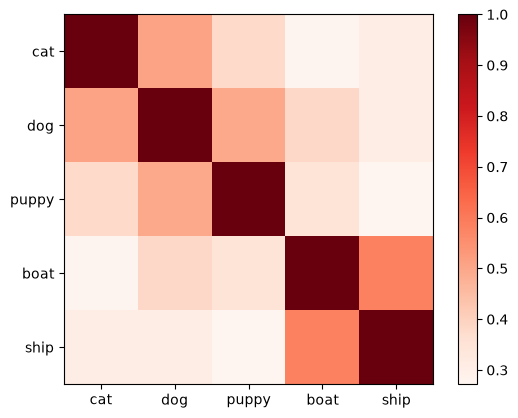

In [5]:
words = ['cat', 'dog', 'puppy', 'boat', 'ship']
ids = [token_id(word) for word in words]
similarity = normed_weight[ids] @ normed_weight[ids].T
fig, ax = plt.subplots()
im = ax.imshow(similarity, cmap='Reds')
ax.set(xticks=range(len(words)), yticks=range(len(words)),
       xticklabels=words, yticklabels=words)
fig.colorbar(im, ax=ax)
plt.show()

## Embedding arithmetic
cool example that 3Blue1Brown popularized.
the math uses the same single token cosine similarity

In [6]:
def get_difference(base, v1, v2):
    base_id, v1_id, v2_id = [token_id(word) for word in (base, v1, v2)]
    target = normed_weight[base_id] + normed_weight[v1_id] - normed_weight[v2_id]
    scores = normed_weight @ target
    scores[list(tokenizer.all_special_ids)] = -float('inf')
    scores[[base_id, v1_id, v2_id]] = -float('inf')
    return tokenizer.convert_ids_to_tokens(scores.argmax().item())

get_difference('king', 'woman', 'man')
get_difference('actor', 'woman', 'man')


'actress'

## Attention in pretrained BERT

custom visulization we stole from bertviz (but made not crash as much)

this show how bert handles its attention layers


In [7]:
with torch.inference_mode():
    outputs = bert(**inputs, output_attentions=True)
print(len(outputs.attentions), outputs.attentions[0].shape)

12 torch.Size([1, 12, 10, 10])


In [8]:
from bertviz_local import head_view

tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0].tolist())
sentence_b_start = inputs['token_type_ids'][0].tolist().index(1)
head_view(outputs.attentions, tokens, sentence_b_start=sentence_b_start, heads=[8])


## Yelp reviews: data for a classifier from scratch

We took the baseline bert tokenizer and removed all the tokens that dont apear in our data.
then we will run the entire thing

In [9]:
from data_paths import load_yelp_dataset

dataset = load_yelp_dataset()
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 560000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 38000
    })
})

In [10]:
print('positive' if dataset['test']['label'][0]  else 'negative')
print(dataset['test']['text'][0])

positive
Contrary to other reviews, I have zero complaints about the service or the prices. I have been getting tire service here for the past 5 years now, and compared to my experience with places like Pep Boys, these guys are experienced and know what they're doing. \nAlso, this is one place that I do not feel like I am being taken advantage of, just because of my gender. Other auto mechanics have been notorious for capitalizing on my ignorance of cars, and have sucked my bank account dry. But here, my service and road coverage has all been well explained - and let up to me to decide. \nAnd they just renovated the waiting room. It looks a lot better than it did in previous years.


In [11]:
from yelp_data import load_yelp_data

device = (torch.accelerator.current_accelerator()
          if torch.accelerator.is_available() else torch.device('cpu'))
MAX_LEN = 512 #(same as bert and we use this constant for choosing the tokenizer. it can be changed but better not)
BATCH_SIZE = 2048
D_MODEL = 32 #16
LAYERS = 2 #3
#giving just 2 layers is kinda tiny (only 1 full attention layer)
#it is still doing suprisingly well with this but there is barely any understanding of structure.
EPOCHS = 1
MAX_TRAIN_STEPS = None
MAX_TEST_STEPS = None

classifier_tokenizer, train_loader, test_loader = load_yelp_data(
    max_len=MAX_LEN, rare_token_limit=5, batch_size=BATCH_SIZE)
VOCAB_SIZE = len(classifier_tokenizer)
PAD_ID = classifier_tokenizer.pad_token_id
ids, labels = next(iter(train_loader))
print(device, ids.shape, labels.shape, VOCAB_SIZE)
print(classifier_tokenizer.convert_ids_to_tokens(ids[0, :16].tolist()))

xpu torch.Size([2048, 512]) torch.Size([2048]) 23767
['[CLS]', 'let', 'me', 'start', 'off', 'by', 'saying', 'one', 'thing', ':', 'i', 'love', 'boo', '##bs', '.', 'but']


## Bidirectional attention with a mask
Here we implement softmax(QK^T)V. there is also a mask we add ontop of that.
masking is fairly simple simply setting the masked attention positions to 0 (usually by setting their score to -inf)

In [12]:
from attention_math_tests import run_attention_math_tests

def attention_math(q, k, v, scale, mask=None):
    scores = (q @ k.transpose(-2, -1)) * scale
    if mask is not None:
        scores = scores.masked_fill(mask, float('-inf'))
    return torch.softmax(scores, dim=-1) @ v

run_attention_math_tests(attention_math)

True

In [13]:
class Attention(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.q = nn.Linear(d, d, bias=False)
        self.k = nn.Linear(d, d, bias=False)
        self.v = nn.Linear(d, d, bias=False)
        self.scale = d ** -0.5

    def forward(self, x, mask):
        return attention_math(self.q(x), self.k(x), self.v(x), self.scale, mask)

## Encoder and binary classification head

Basic model using a GPT style encoding and norm scheme

In [14]:
class Embed(nn.Module):
    def __init__(self, d):
        super().__init__()
        #this is the embedding we saw earlier
        self.tok = nn.Embedding(VOCAB_SIZE, d, padding_idx=PAD_ID)
        #these are positional embeding independent of text
        self.pos = nn.Embedding(MAX_LEN, d)
        self.dropout = nn.Dropout(0.1)

    def forward(self, ids):
        positions = torch.arange(ids.shape[1], device=ids.device)
        return self.dropout(self.tok(ids) + self.pos(positions))

class Block(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.norm1 = nn.LayerNorm(d)
        self.attention = Attention(d)
        self.norm2 = nn.LayerNorm(d)
        self.mlp = nn.Sequential(nn.Linear(d, 4 * d), nn.GELU(), nn.Linear(4 * d, d))

    def forward(self, x, mask):
        x = x + self.attention(self.norm1(x), mask)
        return x + self.mlp(self.norm2(x))

class BertStyleClassifier(nn.Module):
    def __init__(self, d, layers):
        super().__init__()
        self.embed = Embed(d)
        self.blocks = nn.ModuleList([Block(d) for _ in range(layers)])
        self.norm = nn.LayerNorm(d)
        self.head = nn.Linear(d, 1)

    def forward(self, ids):
        mask = (ids == PAD_ID).unsqueeze(1).expand(-1, ids.shape[1], -1)
        x = self.embed(ids)
        for block in self.blocks:
            x = block(x, mask)
        return self.head(self.norm(x[:, 0])).squeeze(-1)

model = BertStyleClassifier(D_MODEL, LAYERS).to(device)
print(f'Randomly initialized parameters: {sum(p.numel() for p in model.parameters()):,}')

Randomly initialized parameters: 800,129


## Training and evaluation


In [15]:
from collections import deque
from itertools import islice
import time
import numpy as np
from tqdm.auto import tqdm

#standar training/eval loop with some metrics.
#this code is not intresting and can be ignored
def run_epoch(model, loader, opt=None, max_steps=None, loss_history=None):
    training = opt is not None
    model.train(training)
    total_loss = total_correct = total_examples = 0
    recent = deque(maxlen=20)
    count = min(len(loader), max_steps) if max_steps is not None else len(loader)
    start = time.perf_counter()
    progress = tqdm(islice(loader, max_steps), total=count,
                    desc='Train' if training else 'Test', unit='batch')
    with torch.set_grad_enabled(training):
        for host_ids, host_labels in progress:
            ids = host_ids.to(device, non_blocking=True)
            labels = host_labels.to(device, non_blocking=True)
            if training:
                opt.zero_grad()
            logits = model(ids)
            loss = F.binary_cross_entropy_with_logits(logits, labels.float())
            if training:
                loss.backward()
                opt.step()
            n = labels.numel()
            batch_loss = loss.item()
            batch_correct = ((logits >= 0).long() == labels).sum().item()
            if training and loss_history is not None:
                loss_history.append(batch_loss)
            total_loss += batch_loss * n
            total_correct += batch_correct
            total_examples += n
            recent.append((batch_loss * n, batch_correct, n))
            recent_examples = sum(item[2] for item in recent)
            progress.set_postfix(loss=f'{total_loss / total_examples:.3f}',
                                 acc=f'{total_correct / total_examples:.1%}',
                                 last20_loss=f'{sum(item[0] for item in recent) / recent_examples:.3f}',
                                 last20_acc=f'{sum(item[1] for item in recent) / recent_examples:.1%}')
    return {'loss': total_loss / total_examples,
            'accuracy': total_correct / total_examples,
            'examples': total_examples, 'seconds': time.perf_counter() - start}

ids, labels = next(iter(train_loader))
logits = model(ids.to(device))
assert logits.shape == (len(labels),)
F.binary_cross_entropy_with_logits(logits, labels.to(device).float()).backward()
model.zero_grad(set_to_none=True)
print('Forward/backward check passed')

Forward/backward check passed


In [ ]:
opt = torch.optim.AdamW(model.parameters(), lr=2e-3)
train_losses = []
test_points = []
for epoch in range(EPOCHS):
    print(f'Epoch {epoch + 1}/{EPOCHS}')
    train_result = run_epoch(model, train_loader, opt, MAX_TRAIN_STEPS, train_losses)
    print('train:', train_result)
    test_result = run_epoch(model, test_loader, max_steps=MAX_TEST_STEPS)
    print('test:', test_result)
    test_points.append((len(train_losses), test_result['loss']))

Epoch 1/1


Train:   0%|          | 0/274 [00:00<?, ?batch/s]

## Loss curves
we will look at the loss going down during training. 
it should be obvious that the model could of been trained fruther. but it did most of the converging

In [ ]:
steps = np.arange(1, len(train_losses) + 1)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(steps, train_losses, alpha=0.3, label='Training batch loss')
window = min(20, len(train_losses))
if window:
    smoothed = np.convolve(train_losses, np.ones(window) / window, mode='valid')
    ax.plot(steps[window - 1:], smoothed, label=f'Training running mean ({window} steps)')
if test_points:
    test_steps, test_losses = zip(*test_points)
    ax.plot(test_steps, test_losses, 'o-', label='Test loss at epoch end')
ax.set(xlabel='Optimizer step', ylabel='Cross-entropy loss')
ax.legend()
plt.show()

## See predictions on held-out reviews

few tests showing how the model actualy preforms. 
While it barely understands languge it gets the general gist of things. but it can get easily confused with confusing languge

In [ ]:
@torch.inference_mode()
def predict_sentiment(text):
    model.eval()
    inputs = classifier_tokenizer(text, truncation=True,
                                  max_length=MAX_LEN, return_tensors='pt')
    logit = model(inputs['input_ids'].to(device))[0]
    positive = torch.sigmoid(logit).item()
    return {'label': 'positive' if positive >= 0.5 else 'negative',
            'positive_probability': positive}


In [ ]:
predict_sentiment("Wow this sucks")

In [ ]:
predict_sentiment("good")

In [ ]:
predict_sentiment("there were a few bad parts but overall very good")

In [ ]:
predict_sentiment("there were a few good parts but it was still quite awful")

In [ ]:
#sarcasem is hard for the model
predict_sentiment("Wow... this was absolutely amazing. They really did get how to make the worse movie")

In [ ]:
# with torch.inference_mode():
#     inputs = classifier_tokenizer("there were a few good parts but it was still quite awful", truncation=True,
#                                       max_length=MAX_LEN, return_tensors='pt')
#     x=model.embed(inputs['input_ids'].to(device))
#     x=model.blocks[0].norm1(x)
#     a = model.blocks[0].attention
#     attention_scores= torch.softmax(a.q(x)@a.k(x).transpose(-2,-1)*a.scale,dim=-1).cpu()[0]


# # words = [classifier_tokenizer.decode(x) for x in inputs['input_ids'][0]]
# # fig, ax = plt.subplots(figsize=(13,13))
# # im = ax.imshow(attention_scores, cmap='Reds')
# # ax.set(xticks=range(len(words)), yticks=range(len(words)),
# #        xticklabels=words, yticklabels=words)
# # fig.colorbar(im, ax=ax)
# # plt.show()

# # The same single-head attention matrix works directly in BertViz.
# from bertviz_local import head_view
# head_view(attention_scores, words)

In [ ]:
# from data_paths import load_yelp_dataset

# dataset = load_yelp_dataset()
# dataset

In [ ]:
# dataset['train']['text'][0]